# To annotate behaviour from timeseries


I am modifying this notebook so that it is more clear what it does.
It takes a Behaviour annotation in a similar format than this:
```
start,end,beh
1,14,Fwd
15,34,Rev
35,59,Coil
60,127,Fwd
128,143,Rev
144,166,Coil
167,178,Fwd
179,211,Rev
212,232,Coil
233,268,Fwd
```
And converts them into a timeseries where everyvolume is annotated.
```
Volume,Description,Annotation
0,Fwd,0.0
1,Fwd,0.0
2,Fwd,0.0
3,Fwd,0.0
4,Fwd,0.0
..

12,Fwd,0.0
13,Fwd,0.0
14,Rev,1.0
15,Rev,1.0
16,Rev,1.0
..
33,Rev,1.0
34,Coil,2.0
35,Coil,2.0
36,Coil,2.0

..
```
And so on

## Steps
### 1. Subsample your behaviour image
If you have more than one behaviour image per datapoint (e.g. wbfm confocal imaging) subsample the image.

If each volume had 22 planes you need to get Use slice keeper with Increment 22 (Fiji>Image>Stacks>Tools>Slice Keeper)

### 2. Manually Annotate Behaviour
(In the future this will be done automatically with PCA cross product Rev annotation)

An easy way to do it is to annotate the starting frame, last frame and behaviour
    
    start,end,beh
    1,30,Fwd
    31,40,Rev
    
   etc.
   
save it in a csv file in the parent directory of the recording as beh_annotation.csv
### 3. Run the code
The code will do what is described in the previous cell.

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import tifffile as tiff
from natsort import natsorted
import glob

In [118]:
# load the manually annotated behaviours
path="/Users/ulises.rey/local_data/test_beh_annotation/1127_w1/turn_annotation.csv"
#'/Volumes/scratch/ulises/wbfm/20211217/data/worm9/beh_annotation.csv'
df=pd.read_csv(path)

In [119]:
# get the max number of volumes (or frames) +1
number_of_volumes=df['end'].max()+1
print(number_of_volumes)

40008


In [120]:
# create a new pandas dataframe
timeline=pd.DataFrame(index=np.arange(number_of_volumes))

In [121]:
# this dictionary links Strings of behaviours to Annotations in numbers
beh_dict={'Fwd': 0,
          'Rev': 1,
          'Coil': 2}

In [122]:
# this dictionary links Strings of behaviours to Annotations in numbers
beh_dict={
    'fwd': 0,
    'rev': 1, 
    'fwd_ventral_turn': 2, #only ventral
    'fwd_dorsal_turn':3, #only dorsal
    'rev_ventral_turn': 4, #only ventral
    'rev_dorsal_turn':5,
    'supercoil': 6#only_dorsal
    }

In [123]:
# iterate over the dataframe and save the data in the timeline dataframe
for row,label in df.iterrows():
    # print(row)
    # print(label)
    # to have cleaner code i specify these variables. -1 is because the first annotation took the fiji indexin which starts with 1
    start=label['start']
    end=label['end']
    beh=label['beh']
    timeline.loc[start:end,'Description']=beh
    timeline.loc[start:end,'Annotation']=int(beh_dict[beh])

#change datatype so that it is then working for imshow() (imshow gives trouble with float 32)
timeline=timeline.astype({"Annotation": np.uint8})

# optional: save index name as 'Volume'
timeline.index.name = 'Volume'

In [124]:
# visualize the result
timeline

,Description,Annotation
Volume,,
0,fwd,0.0
1,fwd,0.0
2,fwd,0.0
3,fwd,0.0
4,fwd,0.0
...,...,...
40003,rev_dorsal_turn,5.0
40004,rev_dorsal_turn,5.0
40005,rev_dorsal_turn,5.0


In [125]:
# save it
output_path="/Users/ulises.rey/local_data/test_beh_annotation/1127_w1/turn_annotation_timeseries.csv"
#'/Volumes/scratch/ulises/wbfm/20211217/data/worm9/beh_annotation_timeseries.csv'
timeline.to_csv(output_path)

In [126]:
a = np.expand_dims(timeline['Annotation'], axis=0)

In [127]:
a

array([[0., 0., 0., ..., 5., 5., 5.]])

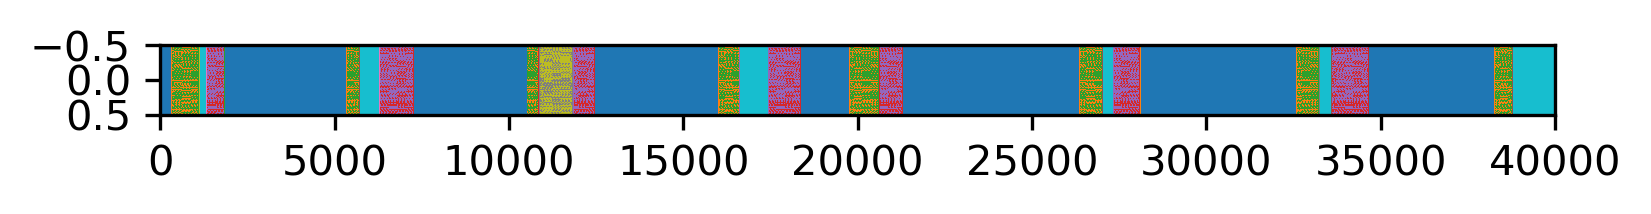

In [128]:
fig, ax = plt.subplots(dpi=300)
ax.imshow(a, origin="upper", cmap='tab10', aspect=20*100)

In [16]:
timeline['Annotation'].values.shape

(40007,)

## Slightly different code for Head Cast Annotation (More parameters to save)

In [3]:
# load the manually annotated behaviours
path="/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221127/data/ZIM2165_Gcamp7b_worm1/2022-11-27_15-14_ZIM2165_worm1_GC7b_Ch0-BH/head_cast_ground_truth.csv"
#'/Volumes/scratch/ulises/wbfm/20211217/data/worm9/beh_annotation.csv'
df=pd.read_csv(path)

In [4]:
df

,start_time,end_time,start_segment,end_segment,sign
0,1447,1804,0,46,dorsal
1,14423,14582,0,15,dorsal
2,15075,15203,0,15,dorsal
3,19222,19330,0,10,dorsal
4,25670,25875,0,20,ventral
5,31588,31720,0,13,dorsal
6,32068,32158,0,11,ventral
7,36196,36498,0,25,dorsal


In [35]:
# create a new pandas dataframe
timeline=pd.DataFrame(index=np.arange(40009))

In [36]:
# iterate over the dataframe and save the data in the timeline dataframe
for row,label in df.iterrows():
    # print(row)
    # print(label)
    # to have cleaner code i specify these variables. -1 is because the first annotation took the fiji indexin which starts with 1
    start=label['start_time']
    end=label['end_time']
    head_cast = 1
    sign=label['sign']
    end_segment = label['end_segment']
    timeline.loc[start:end,'head_cast']=head_cast
    timeline.loc[start:end,'description']=sign
    timeline.loc[start:end,'end_segment']=end_segment
    #timeline.loc[start:end,'Annotation']=int(beh_dict[beh])

#change datatype so that it is then working for imshow() (imshow gives trouble with float 32)
#timeline=timeline.astype({"Annotation": np.uint8})

# optional: save index name as 'Volume'
timeline.index.name = 'Volume'

In [37]:
output_path="/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221127/data/ZIM2165_Gcamp7b_worm1/2022-11-27_15-14_ZIM2165_worm1_GC7b_Ch0-BH/head_cast_ground_truth_timeseries.csv"
#'/Volumes/scratch/ulises/wbfm/20211217/data/worm9/beh_annotation_timeseries.csv'
timeline.to_csv(output_path)

### Run the code for severeal files (Head cast)

In [5]:
path="/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221127/data/ZIM2165_Gcamp7b_worm1/2022-11-27_15-14_ZIM2165_worm1_GC7b_Ch0-BH/head_cast_ground_truth.csv"
os.path.dirname(path)

'/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221127/data/ZIM2165_Gcamp7b_worm1/2022-11-27_15-14_ZIM2165_worm1_GC7b_Ch0-BH'

In [10]:
files = glob.glob("/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221127/data/ZIM2165_Gcamp7b_worm*/*BH/head_cast_ground_truth.csv")

#define number of time points
timeline=pd.DataFrame(index=np.arange(40009))

for file in files:
    print(file)
    df=pd.read_csv(path)
    for row,label in df.iterrows():
        # print(row)
        # print(label)
        # to have cleaner code i specify these variables. -1 is because the first annotation took the fiji indexin which starts with 1
        start=label['start_time']
        end=label['end_time']
        head_cast = 1
        sign=label['sign']
        end_segment = label['end_segment']
        timeline.loc[start:end,'head_cast']=head_cast
        timeline.loc[start:end,'description']=sign
        timeline.loc[start:end,'end_segment']=end_segment
        #timeline.loc[start:end,'Annotation']=int(beh_dict[beh])

    #change datatype so that it is then working for imshow() (imshow gives trouble with float 32)
    #timeline=timeline.astype({"Annotation": np.uint8})

    # optional: save index name as 'Volume'
    timeline.index.name = 'Volume'
    parent_folder =  os.path.dirname(file)
    print(parent_folder)
    output_path=os.path.join(parent_folder, "head_cast_ground_truth_timeseries.csv")
    #'/Volumes/scratch/ulises/wbfm/20211217/data/worm9/beh_annotation_timeseries.csv'
    timeline.to_csv(output_path)

/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221127/data/ZIM2165_Gcamp7b_worm1/2022-11-27_15-14_ZIM2165_worm1_GC7b_Ch0-BH/head_cast_ground_truth.csv
/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221127/data/ZIM2165_Gcamp7b_worm1/2022-11-27_15-14_ZIM2165_worm1_GC7b_Ch0-BH
/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221127/data/ZIM2165_Gcamp7b_worm3/2022-11-27_15-59_ZIM2165_worm3_GC7b_Ch0-BH/head_cast_ground_truth.csv
/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221127/data/ZIM2165_Gcamp7b_worm3/2022-11-27_15-59_ZIM2165_worm3_GC7b_Ch0-BH
/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221127/data/ZIM2165_Gcamp7b_worm4/2022-11-27_16-22_ZIM2165_worm4_GC7b_Ch0-BH/head_cast_ground_truth.csv
/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221127/data/ZIM2165_Gcamp7b_worm4/2022-11-27_16-22_ZIM2165_worm4_GC7b_Ch0-BH
/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221127/data/ZIM2165_Gcamp7b_worm5/2022-11-27_16-42_ZIM2165_worm5_GC7b_Ch0-BH/head_cast_ground_truth.

## Run the code for several files (Not head cast)


In [20]:
main_path = "/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/"
#path=os.path.join(main_path,"202*/data/*/*/ground_truth_beh_annotation/turn_annotation.csv")
path=os.path.join(main_path,"202*/data/*/*/beh_annotation_manual_timeseries.csv")
print(path)
beh_annotation_files = glob.glob(path)
print("there are", len(beh_annotation_files), "turn_annotation.csv files:")
beh_annotation_files 

/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/202*/data/*/*/beh_annotation_manual_timeseries.csv
there are 12 turn_annotation.csv files:


['/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221205/data/ZIM2165_Gcamp7b_worm3/2022-12-05_11-00_ZIM2165_worm3_Ch0-BH/beh_annotation_manual_timeseries.csv',
 '/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221205/data/ZIM2165_Gcamp7b_worm10/2022-12-05_18-06_ZIM2165_worm10_Ch0-BH/beh_annotation_manual_timeseries.csv',
 '/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221210/data/ZIM2165_Gcamp7b_worm2/2022-12-10_16-56_ZIM2165_worm2_Ch0-BH/beh_annotation_manual_timeseries.csv',
 '/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221210/data/ZIM2165_Gcamp7b_worm5/2022-12-10_18-40_ZIM2165_worm5_Ch0-BH/beh_annotation_manual_timeseries.csv',
 '/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221210/data/ZIM2165_Gcamp7b_worm7/2022-12-10_19-47_ZIM2165_worm7_Ch0-BH/beh_annotation_manual_timeseries.csv',
 '/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221210/data/ZIM2165_Gcamp7b_worm8/2022-12-10_20-13_ZIM2165_worm8_Ch0-BH/beh_annotation_manual_timeseries.csv',
 '/Volumes/scr

In [21]:
#Choose a dictionary
# this dictionary links Strings of behaviours to Annotations in numbers
beh_dict={
    'Fwd': -1,
    'Rev': 1, 
    'fwd_ventral_turn': 2,
    'fwd_dorsal_turn':3,
    'rev_ventral_turn': 4,
    'rev_dorsal_turn':5,
    'supercoil': 6,
    'quiescence': 7,
    'Pause': 7,
    'nan':8}

In [22]:
for file in beh_annotation_files:
    print(file)
    df=pd.read_csv(file)
    # get the max number of volumes (or frames) +1
    number_of_volumes=df['end'].max()+1
    print(number_of_volumes)
    # create a new pandas dataframe
    timeline=pd.DataFrame(index=np.arange(number_of_volumes))
    
    # iterate over the dataframe and save the data in the timeline dataframe
    for row,label in df.iterrows():
        # print(row)
        # print(label)
        # to have cleaner code i specify these variables. -1 is because the first annotation took the fiji indexin which starts with 1
        start=label['start']
        end=label['end']
        beh=label['beh']
        timeline.loc[start:end,'Description']=beh
        timeline.loc[start:end,'Annotation']=int(beh_dict[beh])
    #timeline=timeline.astype({"Annotation": np.uint8})

    # optional: save index name as 'Volume'
    timeline.index.name = 'Volume'
    output_path=os.path.join(os.path.dirname(file),"beh_annotation_manual_corrected_timeseries.csv")
    #'/Volumes/scratch/ulises/wbfm/20211217/data/worm9/beh_annotation_timeseries.csv'
    timeline.to_csv(output_path)

/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221205/data/ZIM2165_Gcamp7b_worm3/2022-12-05_11-00_ZIM2165_worm3_Ch0-BH/beh_annotation_manual_timeseries.csv
40009
/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221205/data/ZIM2165_Gcamp7b_worm10/2022-12-05_18-06_ZIM2165_worm10_Ch0-BH/beh_annotation_manual_timeseries.csv
40009
/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221210/data/ZIM2165_Gcamp7b_worm2/2022-12-10_16-56_ZIM2165_worm2_Ch0-BH/beh_annotation_manual_timeseries.csv
40009
/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221210/data/ZIM2165_Gcamp7b_worm5/2022-12-10_18-40_ZIM2165_worm5_Ch0-BH/beh_annotation_manual_timeseries.csv
40009
/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221210/data/ZIM2165_Gcamp7b_worm7/2022-12-10_19-47_ZIM2165_worm7_Ch0-BH/beh_annotation_manual_timeseries.csv
40009
/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221210/data/ZIM2165_Gcamp7b_worm8/2022-12-10_20-13_ZIM2165_worm8_Ch0-BH/beh_annotation_manual_timeseries.csv
40009
/V

In [46]:
timeline["Annotation"]

Volume
0        4
1        4
2        4
3        4
4        4
        ..
40003    0
40004    0
40005    0
40006    0
40007    0
Name: Annotation, Length: 40008, dtype: uint8

## Visualize the ethograms for several recordings:

/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/202*/data/*/*/beh_annotation_manual_corrected_timeseries.csv
there are 12 beh_annotation_timeseries.csv files:
/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221205/data/ZIM2165_Gcamp7b_worm3/2022-12-05_11-00_ZIM2165_worm3_Ch0-BH/beh_annotation_manual_corrected_timeseries.csv


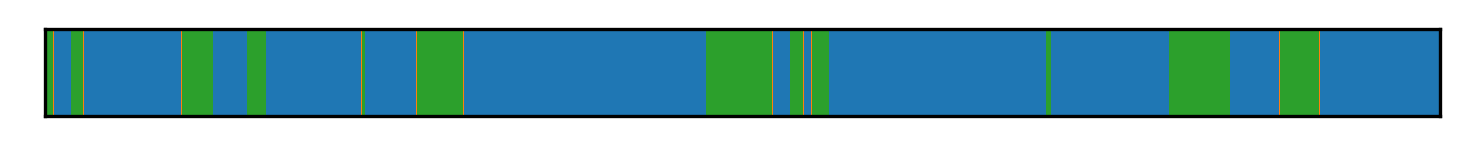

/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221205/data/ZIM2165_Gcamp7b_worm10/2022-12-05_18-06_ZIM2165_worm10_Ch0-BH/beh_annotation_manual_corrected_timeseries.csv


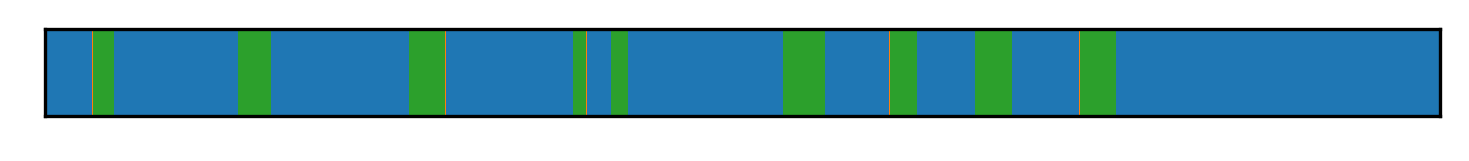

/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221210/data/ZIM2165_Gcamp7b_worm2/2022-12-10_16-56_ZIM2165_worm2_Ch0-BH/beh_annotation_manual_corrected_timeseries.csv


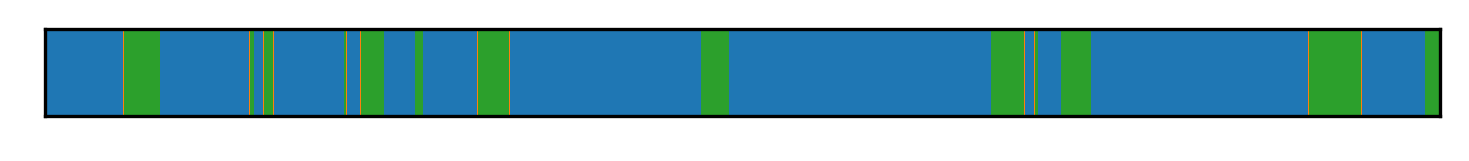

/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221210/data/ZIM2165_Gcamp7b_worm5/2022-12-10_18-40_ZIM2165_worm5_Ch0-BH/beh_annotation_manual_corrected_timeseries.csv


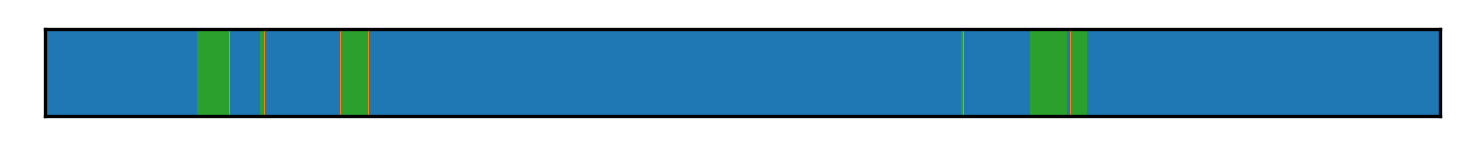

/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221210/data/ZIM2165_Gcamp7b_worm7/2022-12-10_19-47_ZIM2165_worm7_Ch0-BH/beh_annotation_manual_corrected_timeseries.csv


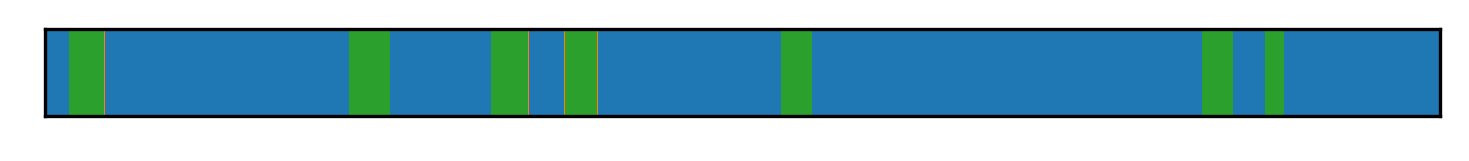

/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221210/data/ZIM2165_Gcamp7b_worm8/2022-12-10_20-13_ZIM2165_worm8_Ch0-BH/beh_annotation_manual_corrected_timeseries.csv


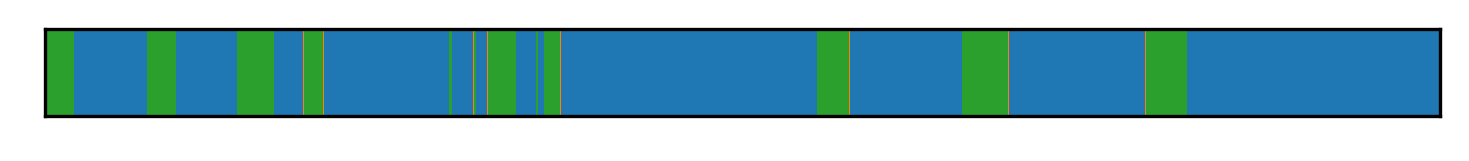

/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221130/data/ZIM2165_Gcamp7b_worm1/2022-11-30_15-38_ZIM2165_worm1_Ch0-BH/beh_annotation_manual_corrected_timeseries.csv


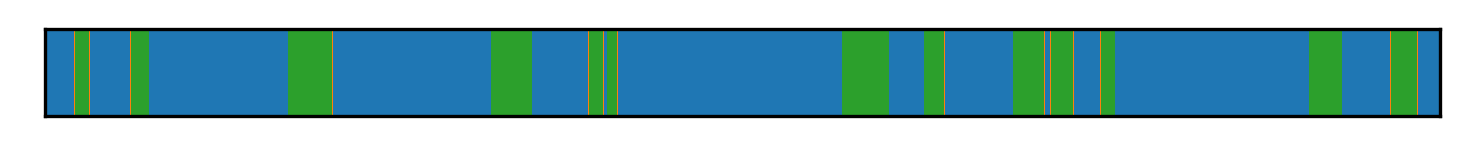

/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221130/data/ZIM2165_Gcamp7b_worm2/2022-11-30_16-34_ZIM2165_worm2_Ch0-BH/beh_annotation_manual_corrected_timeseries.csv


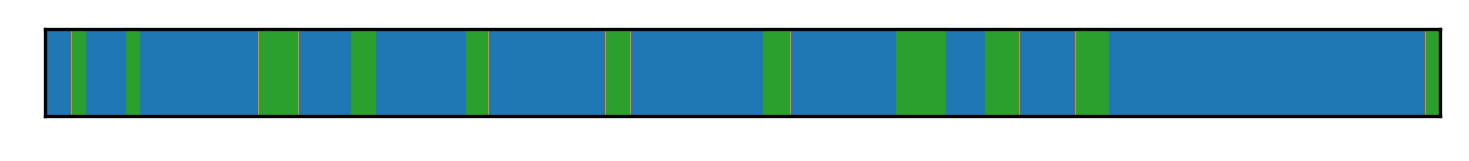

/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221127/data/ZIM2165_Gcamp7b_worm1/2022-11-27_15-14_ZIM2165_worm1_GC7b_Ch0-BH/beh_annotation_manual_corrected_timeseries.csv


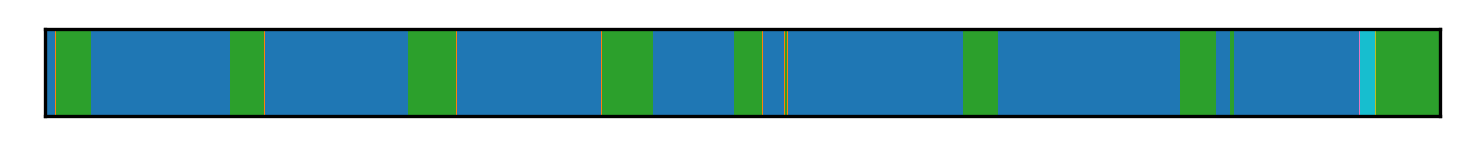

/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221127/data/ZIM2165_Gcamp7b_worm3/2022-11-27_15-59_ZIM2165_worm3_GC7b_Ch0-BH/beh_annotation_manual_corrected_timeseries.csv


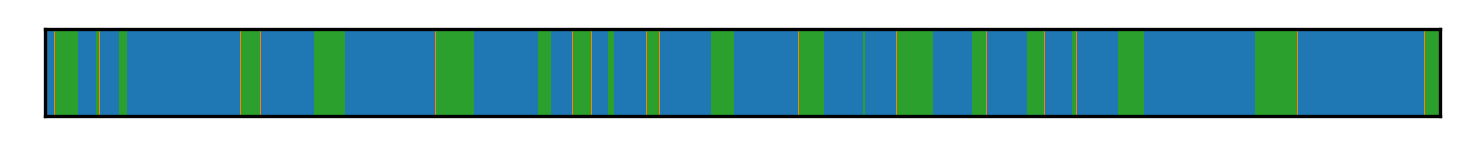

/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221127/data/ZIM2165_Gcamp7b_worm5/2022-11-27_16-42_ZIM2165_worm5_GC7b_Ch0-BH/beh_annotation_manual_corrected_timeseries.csv


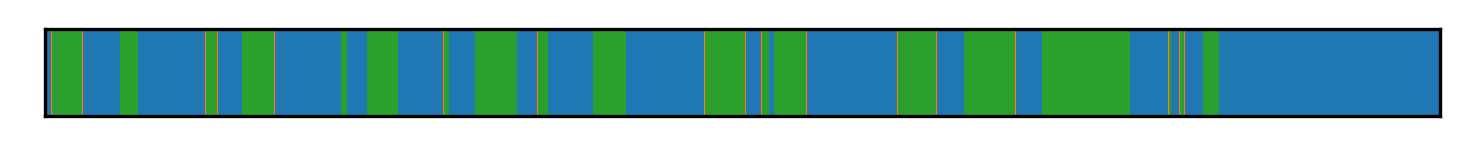

/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221127/data/ZIM2165_Gcamp7b_worm6/2022-11-27_17-10_ZIM2165_worm6_GC7b_Ch0-BH/beh_annotation_manual_corrected_timeseries.csv


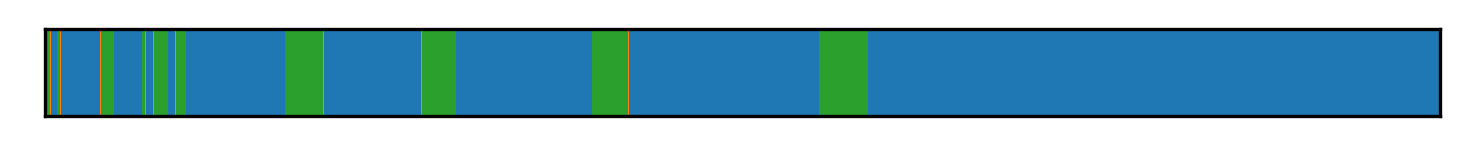

In [23]:
main_path = "/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/"
#path=os.path.join(main_path,"202*/data/*/*/ground_truth_beh_annotation/beh_annotation_timeseries.csv")
path=os.path.join(main_path,"202*/data/*/*/beh_annotation_manual_corrected_timeseries.csv")
print(path)
beh_annotation_files = glob.glob(path)
print("there are", len(beh_annotation_files), "beh_annotation_timeseries.csv files:")
beh_annotation_files 
for file in beh_annotation_files:
    print(file)
    df=pd.read_csv(file)
    df['Annotation']
    a = np.expand_dims(df['Annotation'], axis=0)
    fig, ax = plt.subplots(dpi=300)
    ax.imshow(a, origin="upper", cmap='tab10', aspect=5*500, vmin=-1, vmax=7)#aspect=20*100, vmin=-1, vmax=7) #vmin and vmax are needed to keep colors consistent
    ax.set_ylabel(None)
    ax.set_yticks([])
    ax.set_xlabel(None)
    ax.set_xticks([])
    plt.show()

## Turorial for Johannes

In [1]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


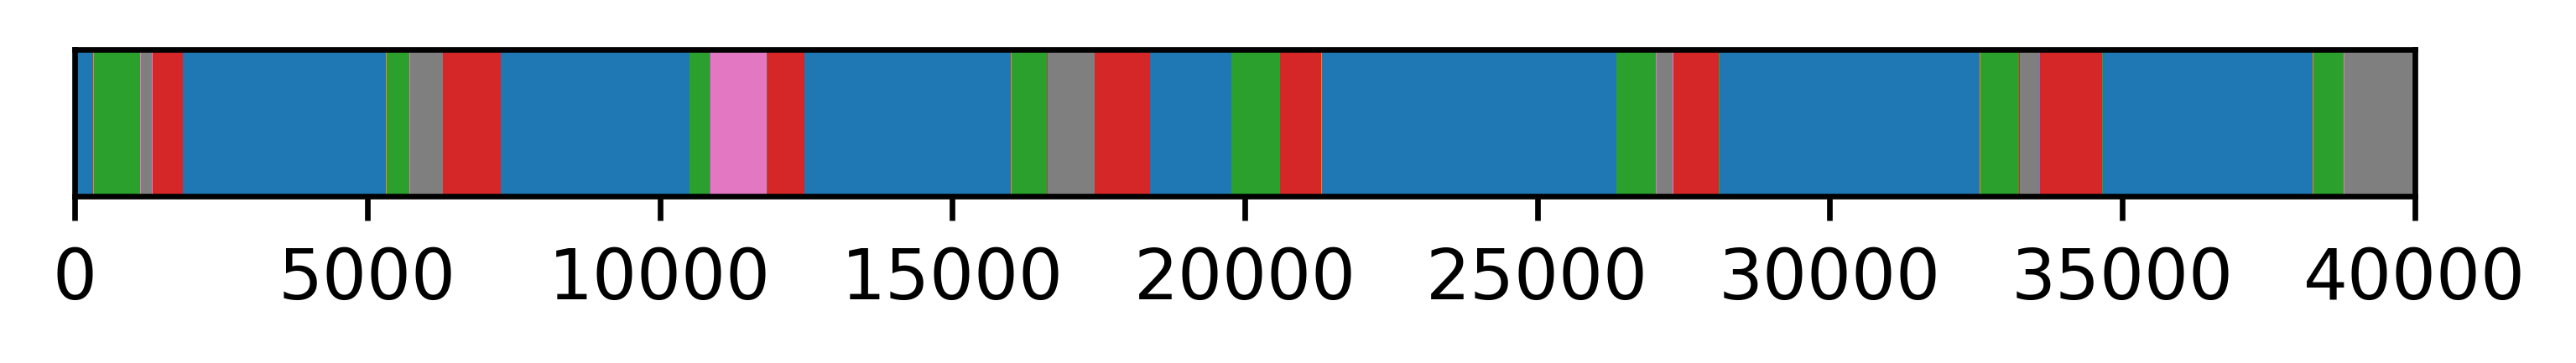

In [4]:
path= "/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221127/data/ZIM2165_Gcamp7b_worm1/2022-11-27_15-14_ZIM2165_worm1_GC7b_Ch0-BH/ground_truth_beh_annotation/beh_annotation_timeseries.csv"

df=pd.read_csv(path)
df['Annotation']
a = np.expand_dims(df['Annotation'], axis=0)
fig, ax = plt.subplots(dpi=600)
ax.plot(a)
ax.imshow(a, origin="upper", cmap='tab10', aspect=5*500, vmin=-1, vmax=7)
ax.set_ylabel(None)
ax.set_yticks([])
#ax.set_xlabel(None)
#ax.set_xticks([])
#ax.set_
plt.show()

## Visualize Turns

In [9]:
import os
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt

/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/202*/data/*/*/turns_annotation.csv
there are 8 turns_annotation.csv files:
/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221123/data/ZIM2165_Gcamp7b_worm8/2022-11-23_14-44_ZIM2165_worm8_Ch0-BH/turns_annotation.csv


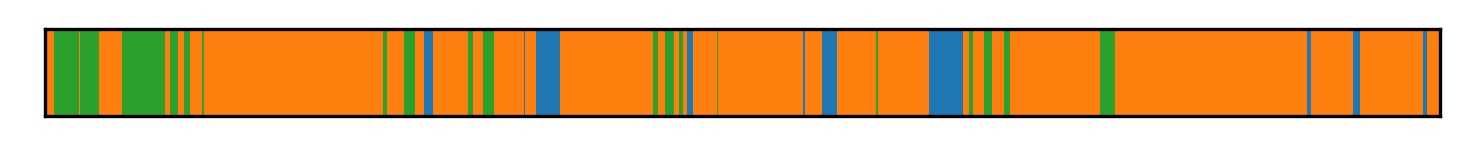

/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221123/data/ZIM2165_Gcamp7b_worm9/2022-11-23_15-07_ZIM2165_worm9_Ch0-BH/turns_annotation.csv


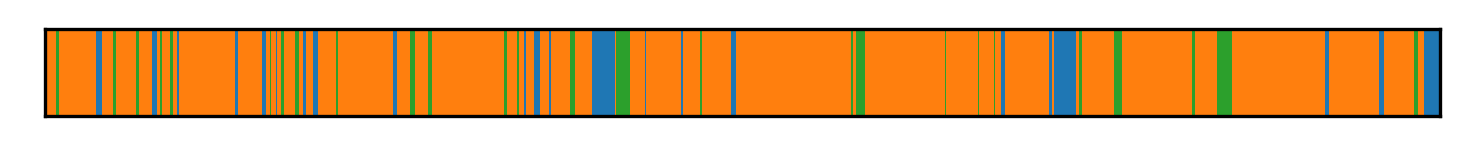

/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221123/data/ZIM2165_Gcamp7b_worm10/2022-11-23_15-32_ZIM2165_worm10_Ch0-BH/turns_annotation.csv


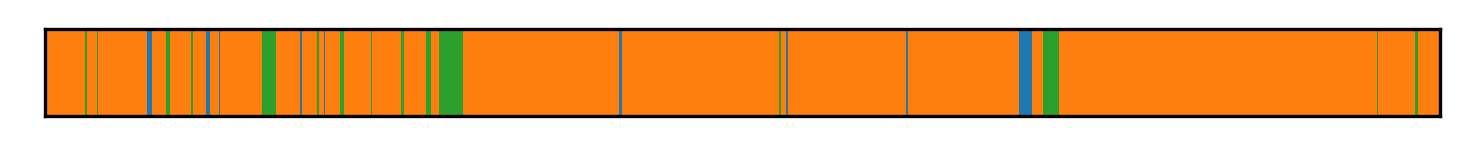

/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221123/data/ZIM2165_Gcamp7b_worm11/2022-11-23_16-00_ZIM2165_worm11_Ch0-BH/turns_annotation.csv


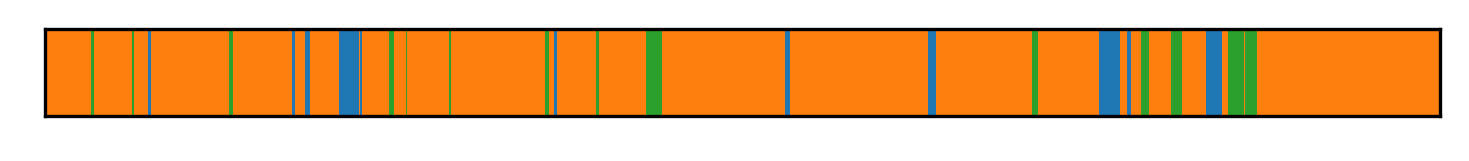

/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221123/data/ZIM2165_Gcamp7b_worm12/2022-11-23_16-39_ZIM2165_worm12_Ch0-BH/turns_annotation.csv


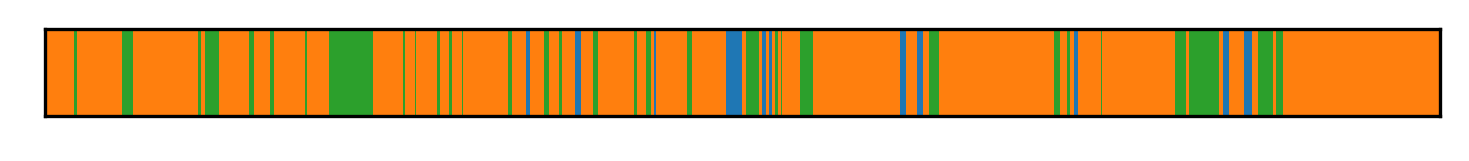

/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221123/data/ZIM2165_Gcamp7b_worm13/2022-11-23_17-44_ZIM2165_worm13_Ch0-BH/turns_annotation.csv


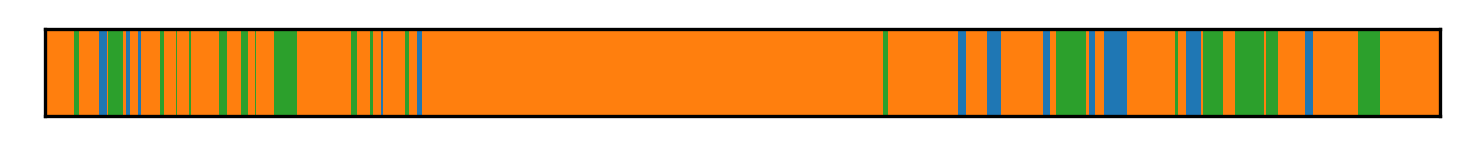

/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221123/data/ZIM2165_Gcamp7b_worm14/2022-11-23_18-05_ZIM2165_worm14_Ch0-BH/turns_annotation.csv


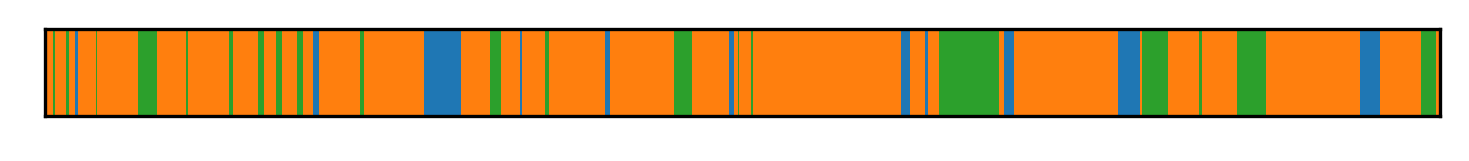

/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/20221123/data/ZIM2165_Gcamp7b_worm15/2022-11-23_18-34_ZIM2165_worm15_Ch0-BH/turns_annotation.csv


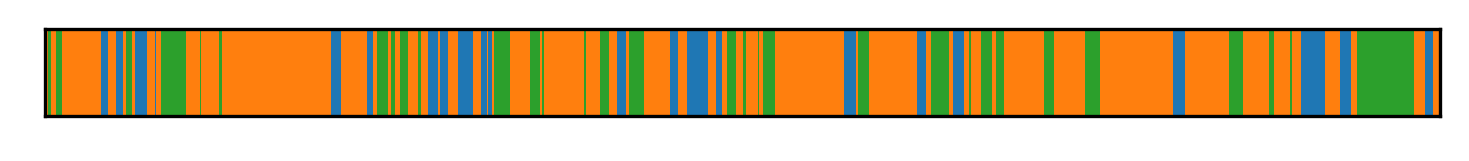

In [10]:
main_path = "/Volumes/scratch/neurobiology/zimmer/ulises/wbfm/"
path=os.path.join(main_path,"202*/data/*/*/turns_annotation.csv")
print(path)
beh_annotation_files = glob.glob(path)
print("there are", len(beh_annotation_files), "turns_annotation.csv files:")
beh_annotation_files 
for file in beh_annotation_files:
    print(file)
    df=pd.read_csv(file)
    df['turn']
    a = np.expand_dims(df['turn'], axis=0)
    fig, ax = plt.subplots(dpi=300)
    ax.imshow(a, origin="upper", cmap='tab10', aspect=5*500, vmin=-1, vmax=7)
    ax.set_ylabel(None)
    ax.set_yticks([])
    ax.set_xlabel(None)
    ax.set_xticks([])
    plt.show()